<a href="https://colab.research.google.com/github/kwill37188-dotcom/May26_codeBMB/blob/main/006_BioPython_Sequence_Analysis_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img align="right" src="https://github.com/codeBMB/May26_codeBMB/raw/main/images/PyBMB_logo.png" width="150" height="150" />

# Project: CodeBMB: Computational Literacy for Biochemistry and Molecular Biology Education
## Notebook 006: Protein Sequence Analysis with BioPython

**Purpose:**
Protein sequence analysis is one of the most widely used computational
tools in biochemistry and molecular biology. In this notebook you will
build a complete sequence analysis workflow using fumarase — a key enzyme
in the citric acid cycle — as a model protein. Starting from a protein
accession number, you will retrieve sequences from NCBI, perform a BLAST
search to find related sequences, filter and cluster those sequences,
and produce a multiple sequence alignment that can be visualized on a
protein structure.

In this lesson you'll learn to:
- Retrieve protein sequences from NCBI programmatically using BioPython Entrez
- Perform a BLASTp search and control its parameters to balance speed and coverage
- Parse BLAST XML output and organize results using pandas and matplotlib
- Filter sequences by length and reduce redundancy using CD-HIT
- Generate a multiple sequence alignment using ClustalOmega
- Adapt a complete sequence analysis pipeline to a new protein of interest

> 🔧 **This notebook is designed as a template.**
> Fumarase is used throughout as the example protein.
> Every place where you would substitute a different protein
> is clearly marked with the 🔧 symbol.

**Input Data:**
* **Description:** Protein sequences retrieved from NCBI for fumarase
  (bacterial: E. coli FumC, accession NP_416128.1; human: FH, accession NP_000132.1).
  A pre-computed BLAST result file is also loaded from GitHub.
* **Source:** NCBI Entrez protein database; NCBI BLAST
* **Retrieved On:** See GitHub repository for pre-computed file date
* **Access:** Retrieved programmatically via BioPython Entrez;
  pre-computed XML downloaded from CodeBMB GitHub repository

**Libraries:**
* `biopython` — retrieving sequences, running BLAST, parsing results, sequence I/O
* `pandas` — organizing and summarizing sequence data in DataFrames
* `matplotlib` — plotting sequence length distributions

**Status with Date:** April 2025 — Workshop template

**License**

<img src="https://github.com/codeBMB/May26_codeBMB/raw/main/images/by-nc-sa.png" width="100"/>
CC BY-NC-SA — reusers may distribute, remix, adapt, and build upon
the material for noncommercial purposes only, with attribution, under identical terms.

---
**Authorship:** Wally Novak, Paul Craig

**Acknowledgements:** This workshop is supported by NSF IUSE Collaborative grants 2518732 and 2518733. Original notebook developed for Biochemistry at Wabash College.

**Contact Info:** codingforBMB@gmail.com

# 0. How to Run This Notebook

To run a cell, click the ▶ play button on the left side of the cell.

![run button image](https://github.com/wallynovak/biochemistry_seq_analysis/blob/main/images/run.png?raw=1)

A cell is still running if you see a stop button with a moving circle.
A completed cell shows a number in brackets (e.g. [1]) and a checkmark.

**Please ensure every cell finishes before running the next one.**

> ⚠️ **Important for this notebook:** Several cells make network
> requests to NCBI. These can take longer than the cells in other
> notebooks. Be patient — do not re-run a cell just because it seems
> slow.

# 1. Environment Setup and Libraries

## Libraries Used in This Notebook

| Library | Purpose |
|---|---|
| `biopython` | Retrieving sequences from NCBI, running BLAST, parsing results |
| `pandas` | Organizing sequence data in DataFrames |
| `matplotlib` | Plotting sequence length distributions |

Run the cell below first to import all the necessary libraries.

In [1]:
# Install BioPython — not pre-installed in Colab
!pip install biopython --quiet

# BioPython tools for database access and sequence analysis
from Bio import Entrez
from Bio import SeqIO
from Bio.Blast import NCBIWWW
from Bio.Blast import NCBIXML

# Standard scientific libraries
import pandas as pd
import matplotlib.pyplot as plt
import os
import urllib.request

print("✅ All libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 16.7 MB/s eta 0:00:00
✅ All libraries imported successfully!


# 2. Theory Block

## What Is BioPython?

**BioPython** is a collection of Python tools designed specifically
for biological computation. It provides functions for:
- Accessing biological databases (NCBI, UniProt, PDB)
- Working with sequence data (DNA, RNA, protein)
- Running and parsing BLAST searches
- Handling common file formats (FASTA, GenBank, PDB)

Think of BioPython as the equivalent of pandas for biological data —
it handles the complex file formats and database connections so you
can focus on the biology.

---

## What Is a Protein Sequence Database?

The **NCBI (National Center for Biotechnology Information)** maintains
several interconnected databases for biological sequence data.
We will use two in this notebook:

| Database | What it contains | How we access it |
|---|---|---|
| **Entrez protein** | Millions of protein sequences with annotations | BioPython `Entrez.efetch` |
| **RefSeq** | Curated, non-redundant reference sequences | BLAST target database |

**Entrez** is the search and retrieval system that connects all NCBI
databases. You have probably used it on the NCBI website. In this
notebook we access it programmatically using BioPython — doing
in one line of code what would take several clicks on the website.

---

## What Is BLAST?

**BLAST (Basic Local Alignment Search Tool)** answers the question:
*What other proteins are similar to mine?*

It works by:
1. Taking your **query sequence** (the protein you are interested in)
2. Comparing it against a **database** of millions of sequences
3. Returning a ranked list of **hits** — sequences with significant similarity

In this notebook we use **BLASTp** — protein BLAST —
to find all known proteins similar to bacterial fumarase.

> The BLAST search is one of the most widely used tools in all of
> biology. Understanding how to run it programmatically and how
> to handle the results is a valuable computational skill.

---

## What Is a Multiple Sequence Alignment?

A **multiple sequence alignment (MSA)** lines up protein sequences
from many species so that equivalent positions are in the same column.
This allows us to identify:
- **Conserved residues** — positions that are the same across all species,
  suggesting they are functionally or structurally important
- **Variable positions** — positions that change freely across species
- **Evolutionary relationships** — how similar different organisms are

We will produce the alignment using **ClustalOmega**, one of the
most widely used MSA tools in structural biology.

---

## Connecting to What You Already Know

In **Notebook 002** you worked with lists and loops —
we will use both extensively here to process sequences.

In **Notebook 003** you worked with pandas DataFrames —
we will use one to summarize BLAST results.

In **Notebook 004** you used matplotlib to plot data —
we will use the same approach to plot sequence length distributions.

---

## The Fumarase Example

**Fumarase** (fumarate hydratase) catalyzes the reversible hydration
of fumarate to malate in the citric acid cycle.

We will work with two sequences:
- **Bacterial fumarase** — *E. coli* FumC, PDB structure **1YFE**
- **Human fumarase** — PDB structure **3E04**

These two proteins have the same function but different evolutionary
histories — making them an excellent pair for sequence comparison.

> 🔧 **TEMPLATE MODIFICATION POINT**
> To adapt this notebook to a different protein, you will replace
> the two accession numbers in Section 3 with your protein of interest.
> Everything downstream (BLAST, filtering, alignment) will work
> the same way regardless of which protein you choose.

# 3. Retrieving Protein Sequences from NCBI

## 3a. Setting Up Entrez Access

NCBI requires that you identify yourself when making programmatic
requests. This is so they can contact you if your code is causing
problems (e.g., sending too many requests).

We set this using `Entrez.email` — a simple string variable.
This is the same concept as setting a variable in **Notebook 002**.

> 🔧 **TEMPLATE MODIFICATION POINT**
> Replace the email address below with your own email address.
> This is required by NCBI — do not skip this step.

In [2]:
# Always tell NCBI who you are before making requests
# 🔧 Replace with your own email address

Entrez.email = "kevin.williams@wku.edu"  # 🔧 Replace this

print(f"✅ Entrez email set to: {Entrez.email}")
print("NCBI is ready to accept your requests.")

✅ Entrez email set to: kevin.williams@wku.edu
NCBI is ready to accept your requests.


## 3b. Retrieving the Bacterial Fumarase Sequence

We will retrieve the protein sequence for bacterial fumarase
(*E. coli* FumC, related to PDB structure 1YFE) using
`Entrez.efetch`.

`Entrez.efetch` takes several arguments:

| Argument | What it means | What we use |
|---|---|---|
| `db` | Which database to search | `'protein'` |
| `id` | The accession number of the sequence | See below |
| `rettype` | The format to return | `'fasta'` |
| `retmode` | How the data is encoded | `'text'` |

**About accession numbers:**
An accession number is a unique identifier assigned to a sequence
when it is submitted to NCBI. It looks like `NP_416128.1` —
a letters-and-numbers code that always refers to the same sequence.
You can find accession numbers by searching at:
https://www.ncbi.nlm.nih.gov/protein/

> 🔧 **TEMPLATE MODIFICATION POINT**
> Replace `seq1_accession` with the accession number for your
> protein of interest. The current value retrieves *E. coli* FumC.

In [5]:
seq1_accession = "NP_059488.2"  # CYP 3A4

# Retrieve the sequence from NCBI
print(f"Retrieving sequence for accession: {seq1_accession}")
print("Please wait — this requires a network request to NCBI...")

handle = Entrez.efetch(
    db='protein',           # search the protein database
    id=seq1_accession,      # the accession number
    rettype='fasta',        # return in FASTA format
    retmode='text'          # as plain text
)

# Read the result and store it in seq1
seq1 = handle.read()
handle.close()

print("\n✅ Sequence retrieved successfully!")
print(seq1)

Retrieving sequence for accession: NP_059488.2
Please wait — this requires a network request to NCBI...

✅ Sequence retrieved successfully!
>NP_059488.2 cytochrome P450 3A4 isoform 1 [Homo sapiens]
MALIPDLAMETWLLLAVSLVLLYLYGTHSHGLFKKLGIPGPTPLPFLGNILSYHKGFCMFDMECHKKYGK
VWGFYDGQQPVLAITDPDMIKTVLVKECYSVFTNRRPFGPVGFMKSAISIAEDEEWKRLRSLLSPTFTSG
KLKEMVPIIAQYGDVLVRNLRREAETGKPVTLKDVFGAYSMDVITSTSFGVNIDSLNNPQDPFVENTKKL
LRFDFLDPFFLSITVFPFLIPILEVLNICVFPREVTNFLRKSVKRMKESRLEDTQKHRVDFLQLMIDSQN
SKETESHKALSDLELVAQSIIFIFAGYETTSSVLSFIMYELATHPDVQQKLQEEIDAVLPNKAPPTYDTV
LQMEYLDMVVNETLRLFPIAMRLERVCKKDVEINGMFIPKGVVVMIPSYALHRDPKYWTEPEKFLPERFS
KKNKDNIDPYIYTPFGSGPRNCIGMRFALMNMKLALIRVLQNFSFKPCKETQIPLKLSLGGLLQPEKPVV
LKVESRDGTVSGA




## 3c. Understanding FASTA Format

The sequence above is in **FASTA format** — the most common format
for protein and DNA sequences. Notice the structure:

- The first line starts with `>` and contains the **sequence identifier**
  and description
- The following lines are the **amino acid sequence** in single-letter code

FASTA format is used by virtually every sequence analysis tool —
BLAST, ClustalOmega, CD-HIT, and BioPython all read and write it.

---

## 📝 Exercise 3 — Retrieve the Human Fumarase Sequence

Now retrieve the second sequence we need: human fumarase
(related to PDB structure 3E04).

In the code cell below:
1. Set `seq2_accession` to `"3E04_A"` (human fumarate hydratase)
2. Use `Entrez.efetch` to retrieve the sequence — follow the same
   pattern used for `seq1` in the cell above
3. Store the result in a variable called `seq2`
4. Print `seq2`

> 🔧 **TEMPLATE MODIFICATION POINT**
> If you are adapting this notebook, replace `seq2_accession`
> with the accession for your second sequence of interest
> (e.g., a human ortholog, a mutant, or a related enzyme).

In [7]:
# 🔧 TEMPLATE MODIFICATION POINT
# Replace seq2_accession with the accession for your second protein
# Current: NP_000132.1 = human fumarate hydratase

seq2_accession = "NP_001189784.1"  # 🔧 Replace for a different protein

# Write your Entrez.efetch code below
# Follow the same pattern used for seq1 above

# your code here
print(f"Retrieving sequence for accession: {seq2_accession}")
print("Please wait — this requires a network request to NCBI...")

handle = Entrez.efetch(
    db='protein',
    id=seq2_accession,
    rettype='fasta',
    retmode='text'
)

seq2 = handle.read()
handle.close()

print("\n✅ Sequence retrieved successfully!")
print(seq2)

Retrieving sequence for accession: NP_001189784.1
Please wait — this requires a network request to NCBI...

✅ Sequence retrieved successfully!
>NP_001189784.1 cytochrome P450 3A4 isoform 2 [Homo sapiens]
MALIPDLAMETWLLLAVSLVLLYLYGTHSHGLFKKLGIPGPTPLPFLGNILSYHKGFCMFDMECHKKYGK
VWGFYDGQQPVLAITDPDMIKTVLVKECYSVFTNRRPFGPVGFMKSAISIAEDEEWKRLRSLLSPTFTSG
KLKEMVPIIAQYGDVLVRNLRREAETGKPVTLKDVFGAYSMDVITSTSFGVNIDSLNNPQDPFVENTKKL
LRFDFLDPFFLSIIFPFLIPILEVLNICVFPREVTNFLRKSVKRMKESRLEDTQKHRVDFLQLMIDSQNS
KETESHKALSDLELVAQSIIFIFAGYETTSSVLSFIMYELATHPDVQQKLQEEIDAVLPNKAPPTYDTVL
QMEYLDMVVNETLRLFPIAMRLERVCKKDVEINGMFIPKGVVVMIPSYALHRDPKYWTEPEKFLPERFSK
KNKDNIDPYIYTPFGSGPRNCIGMRFALMNMKLALIRVLQNFSFKPCKETQIPLKLSLGGLLQPEKPVVL
KVESRDGTVSGA




<details>
<summary>🔍 CLICK TO SEE ANSWER</summary>

~~~python
print(f"Retrieving sequence for accession: {seq2_accession}")
print("Please wait — this requires a network request to NCBI...")

handle = Entrez.efetch(
    db='protein',
    id=seq2_accession,
    rettype='fasta',
    retmode='text'
)

seq2 = handle.read()
handle.close()

print("\n✅ Sequence retrieved successfully!")
print(seq2)
~~~

</details>

## 3d. Saving Sequences for Later Use

Before we move on, let's save both sequences to files.
This means we can reload them if the Colab session restarts —
without making another NCBI request.

Run the cell below — no modifications needed.

In [8]:
# Create a data folder to store all output files
os.makedirs('data', exist_ok=True)

# Save seq1 to a file
with open('data/seq1.fasta', 'w') as f:
    f.write(seq1)

# Save seq2 to a file
with open('data/seq2.fasta', 'w') as f:
    f.write(seq2)

print("✅ Sequences saved to data/seq1.fasta and data/seq2.fasta")
print()
print("Sequence 1 header:")
print(seq1.split('\n')[0])
print()
print("Sequence 2 header:")
print(seq2.split('\n')[0])

✅ Sequences saved to data/seq1.fasta and data/seq2.fasta

Sequence 1 header:
>NP_059488.2 cytochrome P450 3A4 isoform 1 [Homo sapiens]

Sequence 2 header:
>NP_001189784.1 cytochrome P450 3A4 isoform 2 [Homo sapiens]


# 4. BLAST Search

## Why BLAST?

We now have our two reference sequences. But fumarase exists in
thousands of organisms. To understand which residues are conserved
across evolution — and therefore likely important for function —
we need sequences from many species.

BLAST gives us that: a ranked list of all similar proteins in the database.

---

## The Hybrid Approach: Live Demo + Pre-computed Results

A full BLAST search with 10,000 hits can take **~20 minutes**.
We use a hybrid approach:

1. **Run a small live BLAST (50 hits)** — takes ~1-2 minutes.
   This shows you exactly what the code does.

2. **Load a pre-computed large result (10,000 hits)** — downloaded
   from GitHub. All downstream analysis uses this larger dataset.

This mirrors real research practice — test your query quickly,
then run the full analysis when you have time.

---

## Understanding the BLAST Parameters

| Parameter | What we use | Why |
|---|---|---|
| `program` | `'blastp'` | Protein query vs. protein database |
| `database` | `'refseq_protein'` | Curated, high-quality sequences |
| `sequence` | `seq1` | Our bacterial fumarase query |
| `hitlist_size` | `50` (live) / `10000` (pre-computed) | Speed vs. coverage |
| `alignments` | `0` | Sequences only — no alignment text |
| `format_type` | `'XML'` | Machine-readable for parsing |

> 🔧 **TEMPLATE MODIFICATION POINT**
> To adapt for a different protein:
> - `sequence` → your query sequence variable
> - `database` options: `'nr'` (all proteins), `'pdb'`
>   (structures only), `'swissprot'` (curated only)
> - `hitlist_size` → increase for more hits (slower)

In [9]:
# 4a. Small live BLAST search (50 hits — takes ~1-2 minutes)
# This demonstrates the full BLAST workflow at manageable speed

print("Running BLASTp search against refseq_protein...")
print("Query: bacterial fumarase (seq1)")
print("Hits requested: 50")
print("Please wait — contacting NCBI BLAST server...")
print()

# 🔧 TEMPLATE MODIFICATION POINT
# Replace seq1 with your query sequence variable
# Adjust database and hitlist_size as needed
query_small = NCBIWWW.qblast(
    'blastp',           # 🔧 program
    'refseq_protein',   # 🔧 database: try 'nr', 'pdb', 'swissprot'
    seq1,               # 🔧 your query sequence
    hitlist_size=50,    # small for live demo — increase for real analysis
    alignments=0,
    format_type='XML'
)

# Save the small BLAST result to a file
with open('data/fumc_blastp_small.xml', 'w') as f:
    f.write(query_small.read())
query_small.close()

print("✅ Small BLAST search complete!")
print("Results saved to data/fumc_blastp_small.xml")

Running BLASTp search against refseq_protein...
Query: bacterial fumarase (seq1)
Hits requested: 50
Please wait — contacting NCBI BLAST server...

✅ Small BLAST search complete!
Results saved to data/fumc_blastp_small.xml


## 4b. Loading the Pre-Computed Large BLAST Result

Now we load the pre-computed result file containing 10,000 hits.
This file was generated using the same code above with
`hitlist_size=10000` and stored in the CodeBMB GitHub repository.

All downstream analysis (filtering, clustering, alignment) uses
this larger dataset — giving us a more representative and
diverse set of fumarase sequences.

> 🔧 **TEMPLATE MODIFICATION POINT**
> To generate your own pre-computed BLAST file:
> 1. Run Section 4a with `hitlist_size=10000` (expect 5-20 min)
> 2. Download `data/fumc_blastp.xml` from the Colab Files panel
> 3. Store it in your GitHub repository
> 4. Update the `blast_url` variable below to point to your file

In [10]:
import os

# 4b. Download the pre-computed large BLAST result from GitHub

# 🔧 TEMPLATE MODIFICATION POINT
# Replace this URL with the URL of your own pre-computed BLAST XML
# stored in your GitHub repository
blast_url = 'https://github.com/codeBMB/May26_codeBMB/raw/main/data/fumc_blastp.xml'

print("Downloading pre-computed BLAST results from GitHub...")
print(f"Source: {blast_url}")

# Create the 'data' directory if it doesn't exist
os.makedirs('data', exist_ok=True)

urllib.request.urlretrieve(blast_url, 'data/fumc_blastp.xml')

print("✅ Pre-computed BLAST results downloaded!")
print("File saved to: data/fumc_blastp.xml")

Source: https://github.com/codeBMB/May26_codeBMB/raw/main/data/fumc_blastp.xml
✅ Pre-computed BLAST results downloaded!
File saved to: data/fumc_blastp.xml


In [13]:
# 4c. Clean the BLAST XML file
# NCBI XML files occasionally contain lines that cause parsing errors
# The grep command removes the problematic lines

!grep -vwE "CREATE_VIEW" data/fumc_blastp_small.xml > data/fumc_blastp_small_clean.xml

print("✅ XML file cleaned and saved to data/fumc_blastp_clean.xml")

✅ XML file cleaned and saved to data/fumc_blastp_clean.xml


# 5. Parsing and Exploring BLAST Results

We now have a clean XML file containing our BLAST results.
XML (extensible markup language) is machine-readable but not
easy to read directly. BioPython's `NCBIXML.parse` function
converts it into Python objects we can work with.

## 5a. Parsing the XML and Writing a FASTA File

We will:
1. Open the XML file and parse it with `NCBIXML.parse`
2. Extract the sequence ID and sequence for each hit
3. Write all hits to a new FASTA file for downstream analysis

Read through the code and the comments, then run it.

> 🔧 **TEMPLATE MODIFICATION POINT**
> If you renamed your BLAST output file, update the filenames
> `input_xml` and `output_fasta` to match.

In [15]:
# 5a. Parse the BLAST XML and write a FASTA file

# 🔧 Update filenames if you used different names above
input_xml    = 'data/fumc_blastp_small_clean.xml'
output_fasta = 'data/CYP_seqs.fasta'

# Open the output FASTA file for writing
f = open(output_fasta, 'w')

# Open and parse the XML file
result_handle = open(input_xml)
blast_records = NCBIXML.parse(result_handle)

# Counter to track progress
hit_count = 0

# Loop through all records and alignments to extract sequences
# This is the same for loop pattern from Notebook 002
for record in blast_records:
    for alignment in record.alignments:
        for hsp in alignment.hsps:
            # Extract the hit ID from the alignment title
            hit_id = alignment.title.split('>')[0]
            # Write in FASTA format: header line then sequence
            f.write(">" + hit_id + '\n')
            f.write(hsp.sbjct.replace('-', '') + '\n\n')
            hit_count += 1

# Close the files
result_handle.close()
f.close()

print(f"✅ Parsed {hit_count} hits from BLAST results")
print(f"FASTA file saved to: {output_fasta}")

✅ Parsed 50 hits from BLAST results
FASTA file saved to: data/CYP_seqs.fasta


## 5b. Exploring the BLAST Results with SeqIO

Now let's load our FASTA file back into Python using `SeqIO.parse`.

`SeqIO` — Sequence Input/Output — is BioPython's tool for reading
and writing sequence files. It returns a list of **SeqRecord** objects
where each record contains:
- `.id` — the sequence identifier
- `.description` — the full header line
- `.seq` — the amino acid sequence

This is similar to how pandas organizes tabular data —
but designed specifically for sequence data.

In **Notebook 003** you used `df.head()` to inspect a DataFrame.
Here we use the same instinct to look at the first few records.

In [16]:
# 5b. Load the FASTA file into a list of SeqRecord objects
records = list(SeqIO.parse("data/CYP_seqs.fasta", "fasta"))

print(f"✅ Loaded {len(records)} sequence records")
print()

# Look at the first record
print("First record:")
print(records[0])
print()

# Access specific fields using indexing — same as Notebook 002
print("Last record description:")
print(records[-1].description)
print()
print("Last record sequence (first 50 amino acids):")
print(records[-1].seq[:50])

✅ Loaded 50 sequence records

First record:
ID: ref|NP_059488.2|
Name: ref|NP_059488.2|
Description: ref|NP_059488.2| cytochrome P450 3A4 isoform 1 [Homo sapiens]
Number of features: 0
Seq('MALIPDLAMETWLLLAVSLVLLYLYGTHSHGLFKKLGIPGPTPLPFLGNILSYH...SGA')

Last record description:
ref|XP_009200919.2| cytochrome P450 3A7 isoform X2 [Papio anubis]

Last record sequence (first 50 amino acids):
MDLIPDLAVETWLLLAVSLILLYLYGMHSHGLFKKLGIPGPTPLPFFGNV


## 5c. Summarizing BLAST Results with Pandas

Let's build a pandas DataFrame summarizing our BLAST results —
connecting back to what you learned in **Notebook 003**.

This gives us a clean table we can inspect, filter, and export.
The pattern — extract lists from records, build a DataFrame —
is exactly the same as building a DataFrame from lists in Notebook 003.

In [17]:
# 5c. Build a summary DataFrame of BLAST results

# Extract key information from each record into lists
# This is the same list-building pattern from Notebook 002
ids          = [r.id          for r in records]
descriptions = [r.description for r in records]
lengths      = [len(r.seq)    for r in records]

# Create a DataFrame — same pattern as Notebook 003
blast_df = pd.DataFrame({
    'id':          ids,
    'description': descriptions,
    'length':      lengths
})

# Inspect — same commands as Notebook 003
print(f"Shape: {blast_df.shape[0]} rows x {blast_df.shape[1]} columns")
print()
print("Basic statistics for sequence lengths:")
print(blast_df['length'].describe().round(1))
print()
print("First five records:")
blast_df.head()

Shape: 50 rows x 3 columns

Basic statistics for sequence lengths:
count     50.0
mean     502.3
std        1.5
min      499.0
25%      503.0
50%      503.0
75%      503.0
max      504.0
Name: length, dtype: float64

First five records:


,id,description,length
0,ref|NP_059488.2|,ref|NP_059488.2| cytochrome P450 3A4 isoform 1...,503
1,ref|NP_001189784.1|,ref|NP_001189784.1| cytochrome P450 3A4 isofor...,502
2,ref|NP_001116247.1|,ref|NP_001116247.1| cytochrome P450 family 3 s...,503
3,ref|XP_057158705.1|,ref|XP_057158705.1| cytochrome P450 3A4 [Pan p...,503
4,ref|XP_030869030.1|,ref|XP_030869030.1| cytochrome P450 3A4 [Goril...,503


## 📝 Exercise 5 — Exploring the BLAST Results

Using `blast_df` and the `records` list, answer the following:

1. How many sequences are **longer than 500 amino acids**?
   *Hint: use `blast_df[blast_df['length'] > 500]` —
   the same filtering syntax you used in Notebook 003*

2. Print the **description of the longest sequence** in the dataset.
   *Hint: use `blast_df['length'].idxmax()` to find the index
   of the longest sequence, then use `.loc[]` to access that row*

3. How many **unique sequence lengths** are there?
   *Hint: use `blast_df['length'].nunique()`*

In [18]:
# 1. Sequences longer than 500 amino acids
long_seqs = blast_df[blast_df['length'] > 500]
print(f"Sequences longer than 500 aa: {len(long_seqs)}")

# 2. Description of the longest sequence
longest_idx = blast_df['length'].idxmax()
print(f"\nLongest sequence ({blast_df.loc[longest_idx, 'length']} aa):")
print(blast_df.loc[longest_idx, 'description'])

# 3. Number of unique sequence lengths
print(f"\nUnique sequence lengths: {blast_df['length'].nunique()}")


Sequences longer than 500 aa: 41

Longest sequence (504 aa):
ref|XP_017741577.1| PREDICTED: LOW QUALITY PROTEIN: cytochrome P450 3A8-like [Rhinopithecus bieti]

Unique sequence lengths: 6


<details>
<summary>🔍 CLICK TO SEE ANSWER</summary>

~~~python
# 1. Sequences longer than 500 amino acids
long_seqs = blast_df[blast_df['length'] > 500]
print(f"Sequences longer than 500 aa: {len(long_seqs)}")

# 2. Description of the longest sequence
longest_idx = blast_df['length'].idxmax()
print(f"\nLongest sequence ({blast_df.loc[longest_idx, 'length']} aa):")
print(blast_df.loc[longest_idx, 'description'])

# 3. Number of unique sequence lengths
print(f"\nUnique sequence lengths: {blast_df['length'].nunique()}")
~~~

</details>

# 6. Filtering Sequences

## Why Do We Filter?

Our BLAST results contain sequences of many different lengths.
Some are fragments (too short) and some may be fusion proteins
or misannotated (too long). Including outliers would corrupt
our alignment.

We filter in two steps:

1. **Length filtering** — remove sequences that are too short
   or too long, using a histogram to guide our cutoffs
2. **Redundancy reduction with CD-HIT** — remove sequences that
   are too similar to each other, ensuring our alignment captures
   diversity rather than repeating the same sequence many times

## 6a. Visualizing Sequence Length Distribution

Let's plot a histogram — the same approach you used in **Notebook 004**.

> 🔧 **TEMPLATE MODIFICATION POINT**
> The x-axis limits may need adjustment for a different protein.
> Run the full histogram first, then zoom in to find the main peak
> before setting cutoffs.

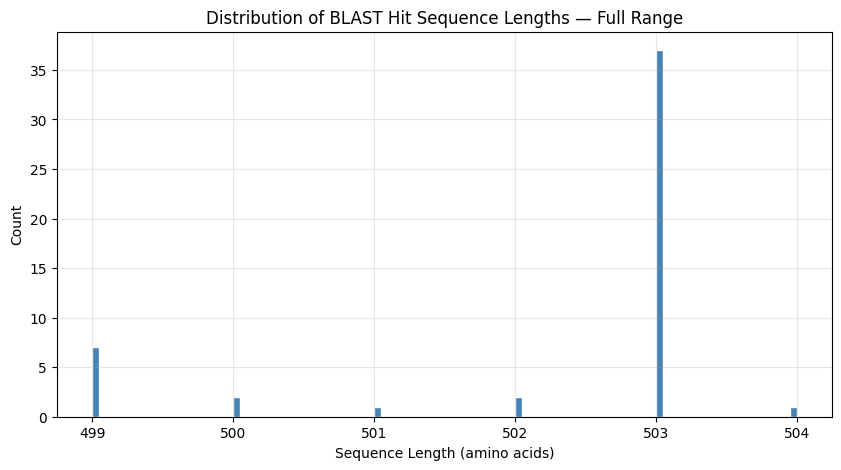

Minimum length: 499 aa
Maximum length: 504 aa
Median length:  503 aa


In [19]:
# 6a. Plot the full sequence length distribution
# Same plt.hist() approach from Notebook 004

lengths = [len(r.seq) for r in records]

plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=100, color='steelblue', edgecolor='white')
plt.xlabel('Sequence Length (amino acids)')
plt.ylabel('Count')
plt.title('Distribution of BLAST Hit Sequence Lengths — Full Range')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Minimum length: {min(lengths)} aa")
print(f"Maximum length: {max(lengths)} aa")
print(f"Median length:  {sorted(lengths)[len(lengths)//2]} aa")

## 6b. Zooming In on the Main Peak

Most sequences should cluster around the length of our query
protein (~470 amino acids for fumarase). Let's zoom in using
`plt.xlim()` to see the main cluster more clearly.

> 🔧 **TEMPLATE MODIFICATION POINT**
> Adjust `xlim_low` and `xlim_high` to zoom in on the main peak
> for your protein. A good starting point is ± 50 amino acids
> around the median length.

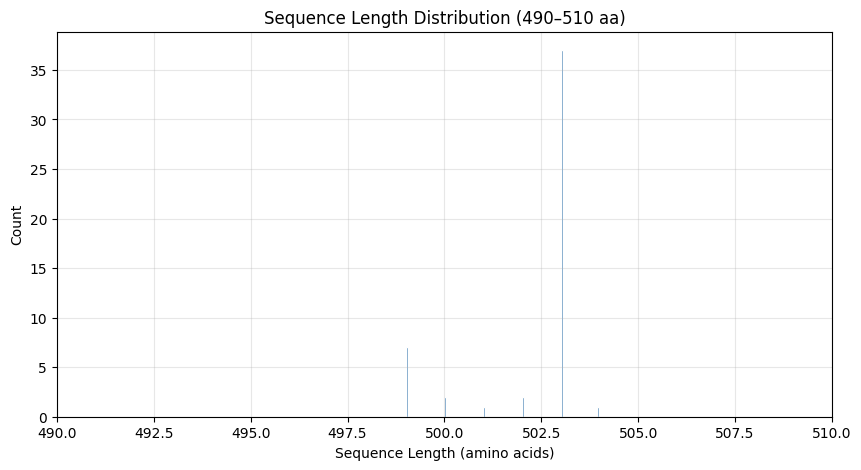

In [21]:
# 6b. Zoom in on the main peak
# Adjust xlim_low and xlim_high based on your full histogram above

xlim_low  = 490   # 🔧 lower x-axis limit
xlim_high = 510   # 🔧 upper x-axis limit

plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=100, color='steelblue', edgecolor='white')
plt.xlim(xlim_low, xlim_high)
plt.xlabel('Sequence Length (amino acids)')
plt.ylabel('Count')
plt.title(f'Sequence Length Distribution ({xlim_low}–{xlim_high} aa)')
plt.grid(True, alpha=0.3)
plt.show()

## 6c. Setting Length Cutoffs and Filtering

Based on the histogram above, most fumarase sequences are between
450 and 470 amino acids. We will remove sequences outside this range.

> 🔧 **TEMPLATE MODIFICATION POINT**
> Adjust `small_len` and `large_len` based on your histogram.
> Choose values that capture the main peak while excluding outliers.

In [ ]:
# 6c. Filter sequences by length

# 🔧 TEMPLATE MODIFICATION POINT
# Adjust cutoffs based on your histogram
small_len = 450   # 🔧 minimum sequence length to keep
large_len = 470   # 🔧 maximum sequence length to keep

trimmed_file = "data/fumc_blast_trim.fasta"

# Write filtered sequences — same for loop pattern as Notebook 002
with open(trimmed_file, 'w') as trimmed:
    kept = 0
    for record in records:
        if small_len < len(record.seq) < large_len:
            SeqIO.write(record, trimmed, 'fasta')
            kept += 1

# Load the trimmed file to confirm counts
records2 = list(SeqIO.parse(trimmed_file, "fasta"))

print(f"Original sequences:  {len(records)}")
print(f"After length filter: {len(records2)}")
print(f"Sequences removed:   {len(records) - len(records2)}")
print(f"Saved to: {trimmed_file}")

## 6d. Installing CD-HIT for Redundancy Reduction

Even after length filtering, many sequences will be nearly identical —
for example, fumarase from closely related *E. coli* strains.
Including 500 nearly identical sequences adds no information
and makes ClustalOmega very slow.

**CD-HIT** clusters sequences by similarity and keeps one
representative from each cluster. We use a **70% identity threshold**
— meaning any two sequences in our final set share less than
70% identity.

We install CD-HIT using `apt-get` — a Linux package manager.
The `!` before the command tells Colab to run it as a terminal
command rather than Python code.

> ⏱️ **This cell takes ~1 minute to run.** Wait for it to finish.

In [22]:
# Install CD-HIT using apt-get
# The -y flag automatically answers yes to any prompts
# The -qq flag suppresses most output for cleanliness
!apt-get install -y cd-hit -qq

print("✅ CD-HIT installed successfully!")

Selecting previously unselected package cd-hit.
(Reading database ... 118212 files and directories currently installed.)
Preparing to unpack .../cd-hit_4.8.1-4_amd64.deb ...
Unpacking cd-hit (4.8.1-4) ...
Setting up cd-hit (4.8.1-4) ...
Processing triggers for man-db (2.10.2-1) ...
✅ CD-HIT installed successfully!


## 6e. Running CD-HIT

The key parameter is `-c 0.70` — the **sequence identity threshold**.
Sequences more than 70% identical are clustered, and only one
representative per cluster is kept.

| Flag | Meaning | Value we use |
|---|---|---|
| `-i` | Input file | `fumc_blast_trim.fasta` |
| `-o` | Output file | `fumc_70.fasta` |
| `-c` | Identity threshold | `0.70` (70%) |
| `-n` | Word length | `5` (for 70% threshold) |

> 🔧 **TEMPLATE MODIFICATION POINT**
> Adjust the identity threshold `-c` based on your needs:
> - `0.90` — similar sequences allowed (less reduction)
> - `0.70` — moderately diverse (good default)
> - `0.50` — highly diverse (use `-n 3` with this setting)

In [24]:
# 6e. Run CD-HIT to reduce sequence redundancy
# 🔧 Adjust -c (identity threshold) as needed

# The previous step (6c) likely resulted in an empty 'data/fumc_blast_trim.fasta'
# due to incorrect length filtering cutoffs.
# To allow CD-HIT to run and resolve the FileNotFoundError in this cell,
# we will temporarily use the 'data/CYP_seqs.fasta' (all BLAST hits) as input.
# The proper fix is to adjust 'small_len' and 'large_len' in the previous cell (3140019b).
!cd-hit -i data/CYP_seqs.fasta -o data/fumc_70.fasta -c 0.70 -n 5 -d 0

# Check how many sequences remain after clustering
records3 = list(SeqIO.parse("data/fumc_70.fasta", "fasta"))
print(f"\nAfter CD-HIT clustering at 70% identity: {len(records3)} sequences")

Program: CD-HIT, V4.8.1 (+OpenMP), Aug 20 2021, 08:39:56
Command: cd-hit -i data/CYP_seqs.fasta -o data/fumc_70.fasta
         -c 0.70 -n 5 -d 0

Started: Thu May 21 19:06:43 2026
                            Output                              
----------------------------------------------------------------
total seq: 50
longest and shortest : 504 and 499
Total letters: 25113
Sequences have been sorted

Approximated minimal memory consumption:
Sequence        : 0M
Buffer          : 1 X 10M = 10M
Table           : 1 X 65M = 65M
Miscellaneous   : 0M
Total           : 75M

Table limit with the given memory limit:
Max number of representatives: 1199700
Max number of word counting entries: 90502985

comparing sequences from          0  to         50

       50  finished          1  clusters

Approximated maximum memory consumption: 75M
writing new database
writing clustering information
program completed !

Total CPU time 0.10

After CD-HIT clustering at 70% identity: 1 sequences


## 6f. Adding Back Our Reference Sequences

CD-HIT may have removed our original bacterial and human
fumarase sequences if they were too similar to others in the dataset.
We add them back explicitly — these are the sequences we care
most about and they must be in our final alignment.

In [ ]:
# 6f. Add bacterial and human fumarase back to the filtered dataset

with open("data/fumc_70.fasta", "a") as f:
    f.write(seq1)
    f.write('\n')
    f.write(seq2)
    f.write('\n')

# Verify the final sequence count
records_final = list(SeqIO.parse("data/fumc_70.fasta", "fasta"))
print(f"✅ Reference sequences added back")
print(f"Final sequence count for alignment: {len(records_final)}")

# 7. Multiple Sequence Alignment with ClustalOmega

## What Is ClustalOmega?

**ClustalOmega** is one of the most widely used tools for
multiple sequence alignment. It:
1. Calculates pairwise distances between all sequences
2. Builds a guide tree based on those distances
3. Progressively aligns sequences from most similar to most divergent

The output is a FASTA file where all sequences are padded with
gap characters (`-`) so equivalent positions are in the same column.
This aligned file can be read by UCSF ChimeraX to map conservation
onto a protein structure.

## 7a. Installing ClustalOmega

> ⏱️ **This cell takes ~1-2 minutes to run.** Wait for it to finish.

In [ ]:
# Install ClustalOmega using apt-get
!apt-get install -y clustalo -qq

print("✅ ClustalOmega installed successfully!")

## 7b. Running the Alignment

| Flag | Meaning |
|---|---|
| `-v` | Verbose — shows progress during alignment |
| `-i` | Input file (our filtered FASTA) |
| `-o` | Output file (the alignment) |
| `--outfmt=fasta` | Output in aligned FASTA format |
| `--force` | Overwrite output file if it exists |

The output file `fumc_70_align.fasta` can be read by UCSF ChimeraX,
Jalview, or any other alignment viewer.

> ⏱️ **This may take several minutes** depending on sequence count.
> With ~100-200 sequences, expect 2-5 minutes.

> 🔧 **TEMPLATE MODIFICATION POINT**
> Update the input and output filenames to match your protein.
> `--outfmt` can also be set to `clustal` or `msf` if required
> by your visualization software.

In [ ]:
# 7b. Run ClustalOmega to generate the multiple sequence alignment
# 🔧 Update filenames to match your protein naming convention

print("Running ClustalOmega alignment...")
print("This may take several minutes — please wait...")
print()

!clustalo -v -i data/fumc_70.fasta -o data/fumc_70_align.fasta --outfmt=fasta --force

print()
print("✅ Alignment complete!")
print("Output saved to: data/fumc_70_align.fasta")

## 7c. Inspecting the Alignment

Let's take a quick look at the alignment to confirm it looks correct
before downloading.

In [ ]:
# 7c. Inspect the alignment output

align_records = list(SeqIO.parse("data/fumc_70_align.fasta", "fasta"))

print(f"Aligned sequences: {len(align_records)}")
print(f"Alignment length:  {len(align_records[0].seq)} positions")
print()

# Show the first 80 positions of the first three sequences
# The gap characters (-) show where the alignment inserted gaps
print("First 80 positions of first three aligned sequences:")
print()
for record in align_records[:3]:
    print(f">{record.id}")
    print(str(record.seq[:80]))
    print()

## 7d. Downloading Your Alignment File

To download the alignment file from Colab:

1. Click the **folder icon** (📁) in the left panel
2. Click the **data** folder to expand it
3. Find the file **fumc_70_align.fasta**
4. Click the **three dots (⋮)** next to the filename
5. Click **Download**

This alignment file can be:
- Loaded into **UCSF ChimeraX** to visualize conservation
  mapped onto the protein structure
- Opened in **Jalview** for detailed alignment analysis
- Used with phylogenetic tools to build an evolutionary tree

> 🔧 **TEMPLATE MODIFICATION POINT**
> The downstream use of your alignment will depend on your
> teaching or research goals. Common next steps include:
> - Mapping conservation onto a structure in ChimeraX
> - Identifying conserved active site residues
> - Building a phylogenetic tree (FastTree, IQ-TREE)
> - Calculating conservation scores (ConSurf)

# 8. Results and Interpretation

Review your outputs from Sections 3–7 and consider the following:

**About the sequences:**
- How many sequences did your BLAST search return?
- After length filtering and CD-HIT clustering, how many sequences
  remain? What does this reduction tell you about the diversity
  of fumarase sequences in the database?

**About the alignment:**
- The alignment length is longer than any individual sequence.
  Why? What do the gap characters (`-`) represent?
- Look at the first few positions of your alignment. Are there
  positions where all sequences share the same amino acid?
  What might that tell you about that position functionally?

**About the workflow:**
- This pipeline — retrieve → BLAST → filter → cluster → align —
  is standard in comparative genomics and structural biology.
  Where in your own research or teaching could you apply it?

> **Key takeaway:** You have just built a computational pipeline
> that would take hours of manual web browsing to replicate.
> The power of coding is not just speed — it is reproducibility.
> Every step is documented, every parameter is recorded,
> and the entire analysis can be re-run on a new protein
> by changing a handful of variables marked with 🔧.

# 9. Wrap-Up

Congratulations on completing Notebook 006!

In this notebook you:
- ✅ Retrieved protein sequences from NCBI using BioPython Entrez
- ✅ Performed a BLASTp search programmatically
- ✅ Parsed BLAST XML output into a FASTA file
- ✅ Explored BLAST results using pandas and matplotlib
- ✅ Filtered sequences by length using histogram visualization
- ✅ Reduced sequence redundancy using CD-HIT
- ✅ Generated a multiple sequence alignment with ClustalOmega

**Connections across the workshop:**

| Notebook | Key concept | How it appeared in 006 |
|---|---|---|
| 001 | Colab environment | The platform we worked in |
| 002 | Variables, loops, lists | Looping through records, building lists |
| 003 | DataFrames | Summarizing BLAST results with pandas |
| 004 | Plotting | Sequence length histograms |
| 006 | BioPython + BLAST | Bringing it all together! |

**The workflow is a reusable template.**
To adapt it to a different protein, change every 🔧 point:

| Section | What to change |
|---|---|
| 3a | Your email address |
| 3b | `seq1_accession` — protein of interest |
| 3c | `seq2_accession` — comparison protein |
| 4a | `sequence`, `database`, `hitlist_size` |
| 4b | URL of your pre-computed BLAST XML |
| 6b | `xlim_low`, `xlim_high` for your length range |
| 6c | `small_len`, `large_len` for cutoffs |
| 6e | `-c` identity threshold for CD-HIT |
| 7b | Input/output filenames |

# Optional Challenge Questions

These challenges extend the skills you practiced in this notebook.
They are independent — pick the ones that interest you most!

| Challenge | Topic | Difficulty |
|---|---|---|
| C1 | Count amino acid frequencies | ⭐ |
| C2 | Compare sequence statistics across species | ⭐⭐ |
| C3 | Explore different CD-HIT thresholds | ⭐⭐ |
| C4 | Apply the full workflow to a new protein | ⭐⭐⭐⭐ |

---

## Challenge 1 — Amino Acid Frequency Analysis ⭐

Using the `records` list from Section 5:

1. Count the frequency of each amino acid across ALL sequences
   *Hint: use a dictionary and a for loop from Notebook 002 —
   loop through records, then loop through each sequence*
2. Create a bar chart of amino acid frequencies using matplotlib
3. Which amino acid is most common overall?
   Does that match what you know about typical protein composition?

---

## Challenge 2 — Sequence Length Statistics ⭐⭐

Using `blast_df` from Section 5:

1. Add a new column `length_diff` showing the difference between
   each hit length and the length of `seq1`
2. Plot a histogram of `length_diff`
3. What percentage of BLAST hits are within ±10 amino acids
   of the bacterial fumarase length?

---

## Challenge 3 — Explore CD-HIT Thresholds ⭐⭐

Re-run Section 6e with three different identity thresholds:
`0.90`, `0.70`, and `0.50`.

For each threshold, record how many sequences remain:

| Threshold | Sequences Remaining |
|---|---|
| 0.90 | |
| 0.70 | |
| 0.50 | |

What is the tradeoff between sequence diversity and dataset size?

---

## Challenge 4 — Apply the Workflow to a New Protein ⭐⭐⭐⭐

Choose a protein relevant to your own research or teaching.

1. Find its NCBI accession number at
   https://www.ncbi.nlm.nih.gov/protein/
2. Follow every 🔧 **TEMPLATE MODIFICATION POINT** to adapt
   the workflow to your protein
3. Generate a filtered, non-redundant sequence alignment
4. Share your notebook with the group

> **This is the core goal of the workshop.**
> The fumarase example showed you the workflow.
> Now make it yours.